# compare the best of two models

In [1]:
import numpy as np
import os
import glob
from matplotlib import pyplot as plt
from src.evaluation import plotting
from src.evaluation.inference import Sampler
from IPython.display import Image, display
from plotting_rules import colours, pretty_names, tag_from_sample_path
img_dir = "/data/dust/user/dayhallh/data/CaloClouds_diffusion/imgs/"

In [10]:
# took too long
#log_dir = "/data/dust/user/dayhallh/data/CaloClouds_diffusion/old_logs_3/2026_08_17__15_20_42/"  # sim
#log_dir = "/data/dust/user/dayhallh/data/CaloClouds_diffusion/old_logs_3/2026_08_17__15_21_09/"  # geant_4

# First ones that (kinda) worked
#log_dir = "/data/dust/user/dayhallh/data/CaloClouds_diffusion/old_logs_5/2026_08_17__15_19_32"  # padded photon 1, quite good, not amazing
#log_dir = "/data/dust/user/dayhallh/data/CaloClouds_diffusion/old_logs_5/2026_08_17__19_06_34/" # Padded_All 1, training ended, not that good

# Poor starting choices
#log_dir = "/data/dust/user/dayhallh/data/CaloClouds_diffusion/old_logs_4/2026_08_18__09_27_22/" # Padded photon 2
#log_dir = "/data/dust/user/dayhallh/data/CaloClouds_diffusion/old_logs_4/2026_08_18__09_27_42/" # Padded all 2
#log_dir = "/data/dust/user/dayhallh/data/CaloClouds_diffusion/old_logs_7/2026_08_18__12_06_30/" # padded photons 3, somehow broken

# latest with good starting choices
log_dir1 = "/data/dust/user/dayhallh/data/CaloClouds_diffusion/logs/2026_08_23__17_38_36/" # padded photons 3, try 2
log_dir2 = "/data/dust/user/dayhallh/data/CaloClouds_diffusion/logs/2026_08_18__12_06_34/" # padded all 3, best yet

# first distilled
log_dirD_1 = "/data/dust/user/dayhallh/data/CaloClouds_diffusion/logs/2026_08_18__17_17_55/" # distilled from photons 3, but not after the end of training
log_dirD_2 = "/data/dust/user/dayhallh/data/CaloClouds_diffusion/logs/2026_08_21__10_32_03/" # distilled from photons 3, but not after the end of training

# new moe/mos
log_dir3 =  "/data/dust/user/dayhallh/data/CaloClouds_diffusion/logs/2026_08_20__17_04_20/"  # working generalist and moe
log_dir4 =  "/data/dust/user/dayhallh/data/CaloClouds_diffusion/logs/2026_08_19__22_38_22/"  # working only moe
log_dir5 =  "/data/dust/user/dayhallh/data/CaloClouds_diffusion/logs/2026_08_20__16_56_40/"  # working only mos
log_dir6 =  "/data/dust/user/dayhallh/data/CaloClouds_diffusion/logs/2026_08_19__22_43_47/"  # working generalist and mos

logs_to_compare = [log_dir0, log_dir6] # not done yet
show_cc3 = True
use_ema = True

#summary_suffix = "_summary.npz"
#summary_suffix = "_rescaled_energy_summary.npz"
summary_suffix = "_external_cond_rescaled_energy_summary.npz"
best_records = []
infos = []
save_name = "Compare"

if use_ema:
    save_name += "_emas"
if show_cc3:
    save_name += "_CC3"
for log_dir in logs_to_compare:
    if not os.path.exists(log_dir):
        print(f"Can't find {log_dir}")
    info = os.path.basename(glob.glob(os.path.join(log_dir, "_a_*"))[0])[3:].replace("_", " ")
    infos.append(info)
    print(info)
    comp_name = pretty_names[info].replace(" ", "")
    save_name += "_" + comp_name
    best_record = os.path.join(log_dir, "last_best_seen.txt")
    if os.path.exists(best_record):
        with open(best_record, 'r') as ff:
            best_model_path = ff.read().strip()
        if use_ema:
            best_model_path = best_model_path.replace("model", "ema_model")

        print(f"The best checkpoint is {best_model_path}")
    else:
        print(f"Can't see a {best_record}, consider running scripts/generate_summary_plots_best.py")
   
    best_records.append(best_model_path)
#best_records[1] = "/data/dust/user/dayhallh/data/CaloClouds_diffusion/logs/2026_08_18__12_06_30/checkpoints/2026-08-19_11-47-28_ema_model.pt"
#best_records[0] = "/data/dust/user/dayhallh/data/CaloClouds_diffusion/logs/2026_08_18__12_06_34/checkpoints/2026-08-19_11-10-21_model.pt"
#best_records[1] = "/data/dust/user/dayhallh/data/CaloClouds_diffusion/logs/2026_08_18__12_06_30/checkpoints/2026-08-19_07-39-24_model.pt"
for level in ["data", "cells"]:
    for model_path in best_records:
        try:
            event_index = 100
            display(Image(filename=f'{model_path[:-3]}_{level}_{event_index}.png'))
        except FileNotFoundError:
            continue

save_base = os.path.join(img_dir, save_name)
print(save_base)

padded photons v2
The best checkpoint is /data/dust/user/dayhallh/data/CaloClouds_diffusion/logs/2026_08_23__17_38_36/checkpoints/2026-08-24_19-58-02_ema_model.pt
generalist and moe all
The best checkpoint is /data/dust/user/dayhallh/data/CaloClouds_diffusion/logs/2026_08_19__22_43_47/checkpoints/2026-08-21_18-01-27_ema_model.pt
/data/dust/user/dayhallh/data/CaloClouds_diffusion/imgs/Compare_emas_CC3_OnlyPhotons_GeneralistandMoE


In [11]:
ref_paths = ["/data/dust/user/dayhallh/data/CaloClouds_diffusion/precalculated_reference/geant4_/pretest_Total1000_NoPick.npz",
             "/data/dust/user/dayhallh/data/CaloClouds_diffusion/precalculated_reference/Padded_photon_full_/pretest_Total1000_NoPick.npz",
             "/data/dust/user/dayhallh/data/CaloClouds_diffusion/precalculated_reference/Padded_All_/pretest_Total1000_NoPick.npz",
             "/data/dust/user/dayhallh/data/CaloClouds_diffusion/precalculated_reference/sim-E1261AT600AP180-180_file_/pretest_Total1000_NoPick.npz",
            ]

ref_path = ref_paths[2]


sample_paths = [model_path.replace(".pt", summary_suffix) for model_path in best_records]
if show_cc3:
    cc3_path = "/data/dust/user/dayhallh/data/CaloClouds_diffusion/CC3_showers_external_cond_rescaled_energy_summary.h5.npz"
    sample_paths.append(cc3_path)
    infos.append("cc3")

print(sample_paths)

ref = np.load(ref_path)
# first dimension is events
print(len(ref.keys()), {key:ref[key].shape for key in list(ref.keys())})

['/data/dust/user/dayhallh/data/CaloClouds_diffusion/logs/2026_08_23__17_38_36/checkpoints/2026-08-24_19-58-02_ema_model_external_cond_rescaled_energy_summary.npz', '/data/dust/user/dayhallh/data/CaloClouds_diffusion/logs/2026_08_19__22_43_47/checkpoints/2026-08-21_18-01-27_ema_model_external_cond_rescaled_energy_summary.npz', '/data/dust/user/dayhallh/data/CaloClouds_diffusion/CC3_showers_external_cond_rescaled_energy_summary.h5.npz']
52 {'cond': (1000, 7), 'pca': (1000, 3), 'pca_top4': (1000, 3), 'event_energy': (1000,), 'cell_energies': (1000, 99), 'cell_energies_edges': (100,), 'layer_energies': (1000, 78), 'layer_occupancies': (1000, 78), 'event_occupancies': (1000,), 'radial_energy': (1000, 49), 'radial_energy_edges': (50,), 'radial_occupancies': (1000, 49), 'radial_occupancies_edges': (50,), 'pdg_-11_cond': (340, 7), 'pdg_-11_pca': (340, 3), 'pdg_-11_pca_top4': (340, 3), 'pdg_-11_event_energy': (340,), 'pdg_-11_cell_energies': (340, 99), 'pdg_-11_cell_energies_edges': (100,), 'p

In [12]:

def pca_to_angles(pca):
    """Convert pca direction vectors into (theta, phi) angles.

    theta is measured from the z axis, phi is the angle in the x-y plane.
    """
    x = pca[:, 0]
    y = pca[:, 1]
    z = pca[:, 2]
    r = np.sqrt(x**2 + y**2 + z**2)
    theta = np.arccos(np.clip(z / r, -1.0, 1.0))
    phi = np.arctan2(y, x)
    return theta, phi


def augment_with_angles(data):
    """Return a dict copy of data with pca keys replaced by angle keys."""
    augmented = {}
    for key in data.keys():
        if "pca" in key and not key.endswith("_edges"):
            theta, phi = pca_to_angles(data[key])
            augmented[f"{key}_theta"] = theta
            augmented[f"{key}_phi"] = phi
        else:
            augmented[key] = data[key]
    return augmented


def bin_heights_and_edges(data, key):
    """Compute bin heights and edges for a given key."""
    values = data[key]
    edges_key = f"{key}_edges"
    if edges_key in data:
        edges = data[edges_key]
        heights = np.mean(values, axis=0)
        errors = np.std(values, axis=0)/np.sqrt(values.shape[0])
    elif values.ndim == 1:
        ref_values = data[key]
        if not len(ref_values):
            raise ValueError(f"Missing {key}")
        r_min, r_max = np.nanmin(ref_values), np.nanmax(ref_values)
        if abs(r_min - r_max) < 2:
            r_min -= 1
            r_max += 1
        r_min -= abs(r_min*0.1)
        r_max += abs(r_max*0.1)
        edges = np.linspace(r_min, r_max, 51)
        heights, _ = np.histogram(values, bins=edges)
        errors = np.sqrt(heights)/len(values)
        heights = heights/len(values)
    else:
        heights = np.mean(values, axis=0)
        errors = np.std(values, axis=0)/np.sqrt(values.shape[0])
        edges = np.linspace(0, heights.shape[0], heights.shape[0] + 1)
    if "radial" in key:
        # didn't divide through by area of hollow circle when collecting the data
        area_of_circles = np.pi * edges**2
        area_of_bins = area_of_circles[1:] - area_of_circles[:-1]
        heights /= area_of_bins
        errors /= area_of_bins**2
    return heights, edges, errors



/data/dust/user/dayhallh/data/CaloClouds_diffusion/logs/2026_08_23__17_38_36/checkpoints/2026-08-24_19-58-02_ema_model_external_cond_rescaled_energy_summary.npz
dict_keys(['cond', 'pca_theta', 'pca_phi', 'pca_top4_theta', 'pca_top4_phi', 'event_energy', 'cell_energies', 'cell_energies_edges', 'layer_energies', 'layer_occupancies', 'event_occupancies', 'radial_energy', 'radial_energy_edges', 'radial_occupancies', 'radial_occupancies_edges'])
/data/dust/user/dayhallh/data/CaloClouds_diffusion/logs/2026_08_19__22_43_47/checkpoints/2026-08-21_18-01-27_ema_model_external_cond_rescaled_energy_summary.npz
dict_keys(['cond', 'pca_theta', 'pca_phi', 'pca_top4_theta', 'pca_top4_phi', 'event_energy', 'cell_energies', 'cell_energies_edges', 'layer_energies', 'layer_occupancies', 'event_occupancies', 'radial_energy', 'radial_energy_edges', 'radial_occupancies', 'radial_occupancies_edges', 'pdg_-11_cond', 'pdg_-11_pca_theta', 'pdg_-11_pca_phi', 'pdg_-11_pca_top4_theta', 'pdg_-11_pca_top4_phi', 'pdg_

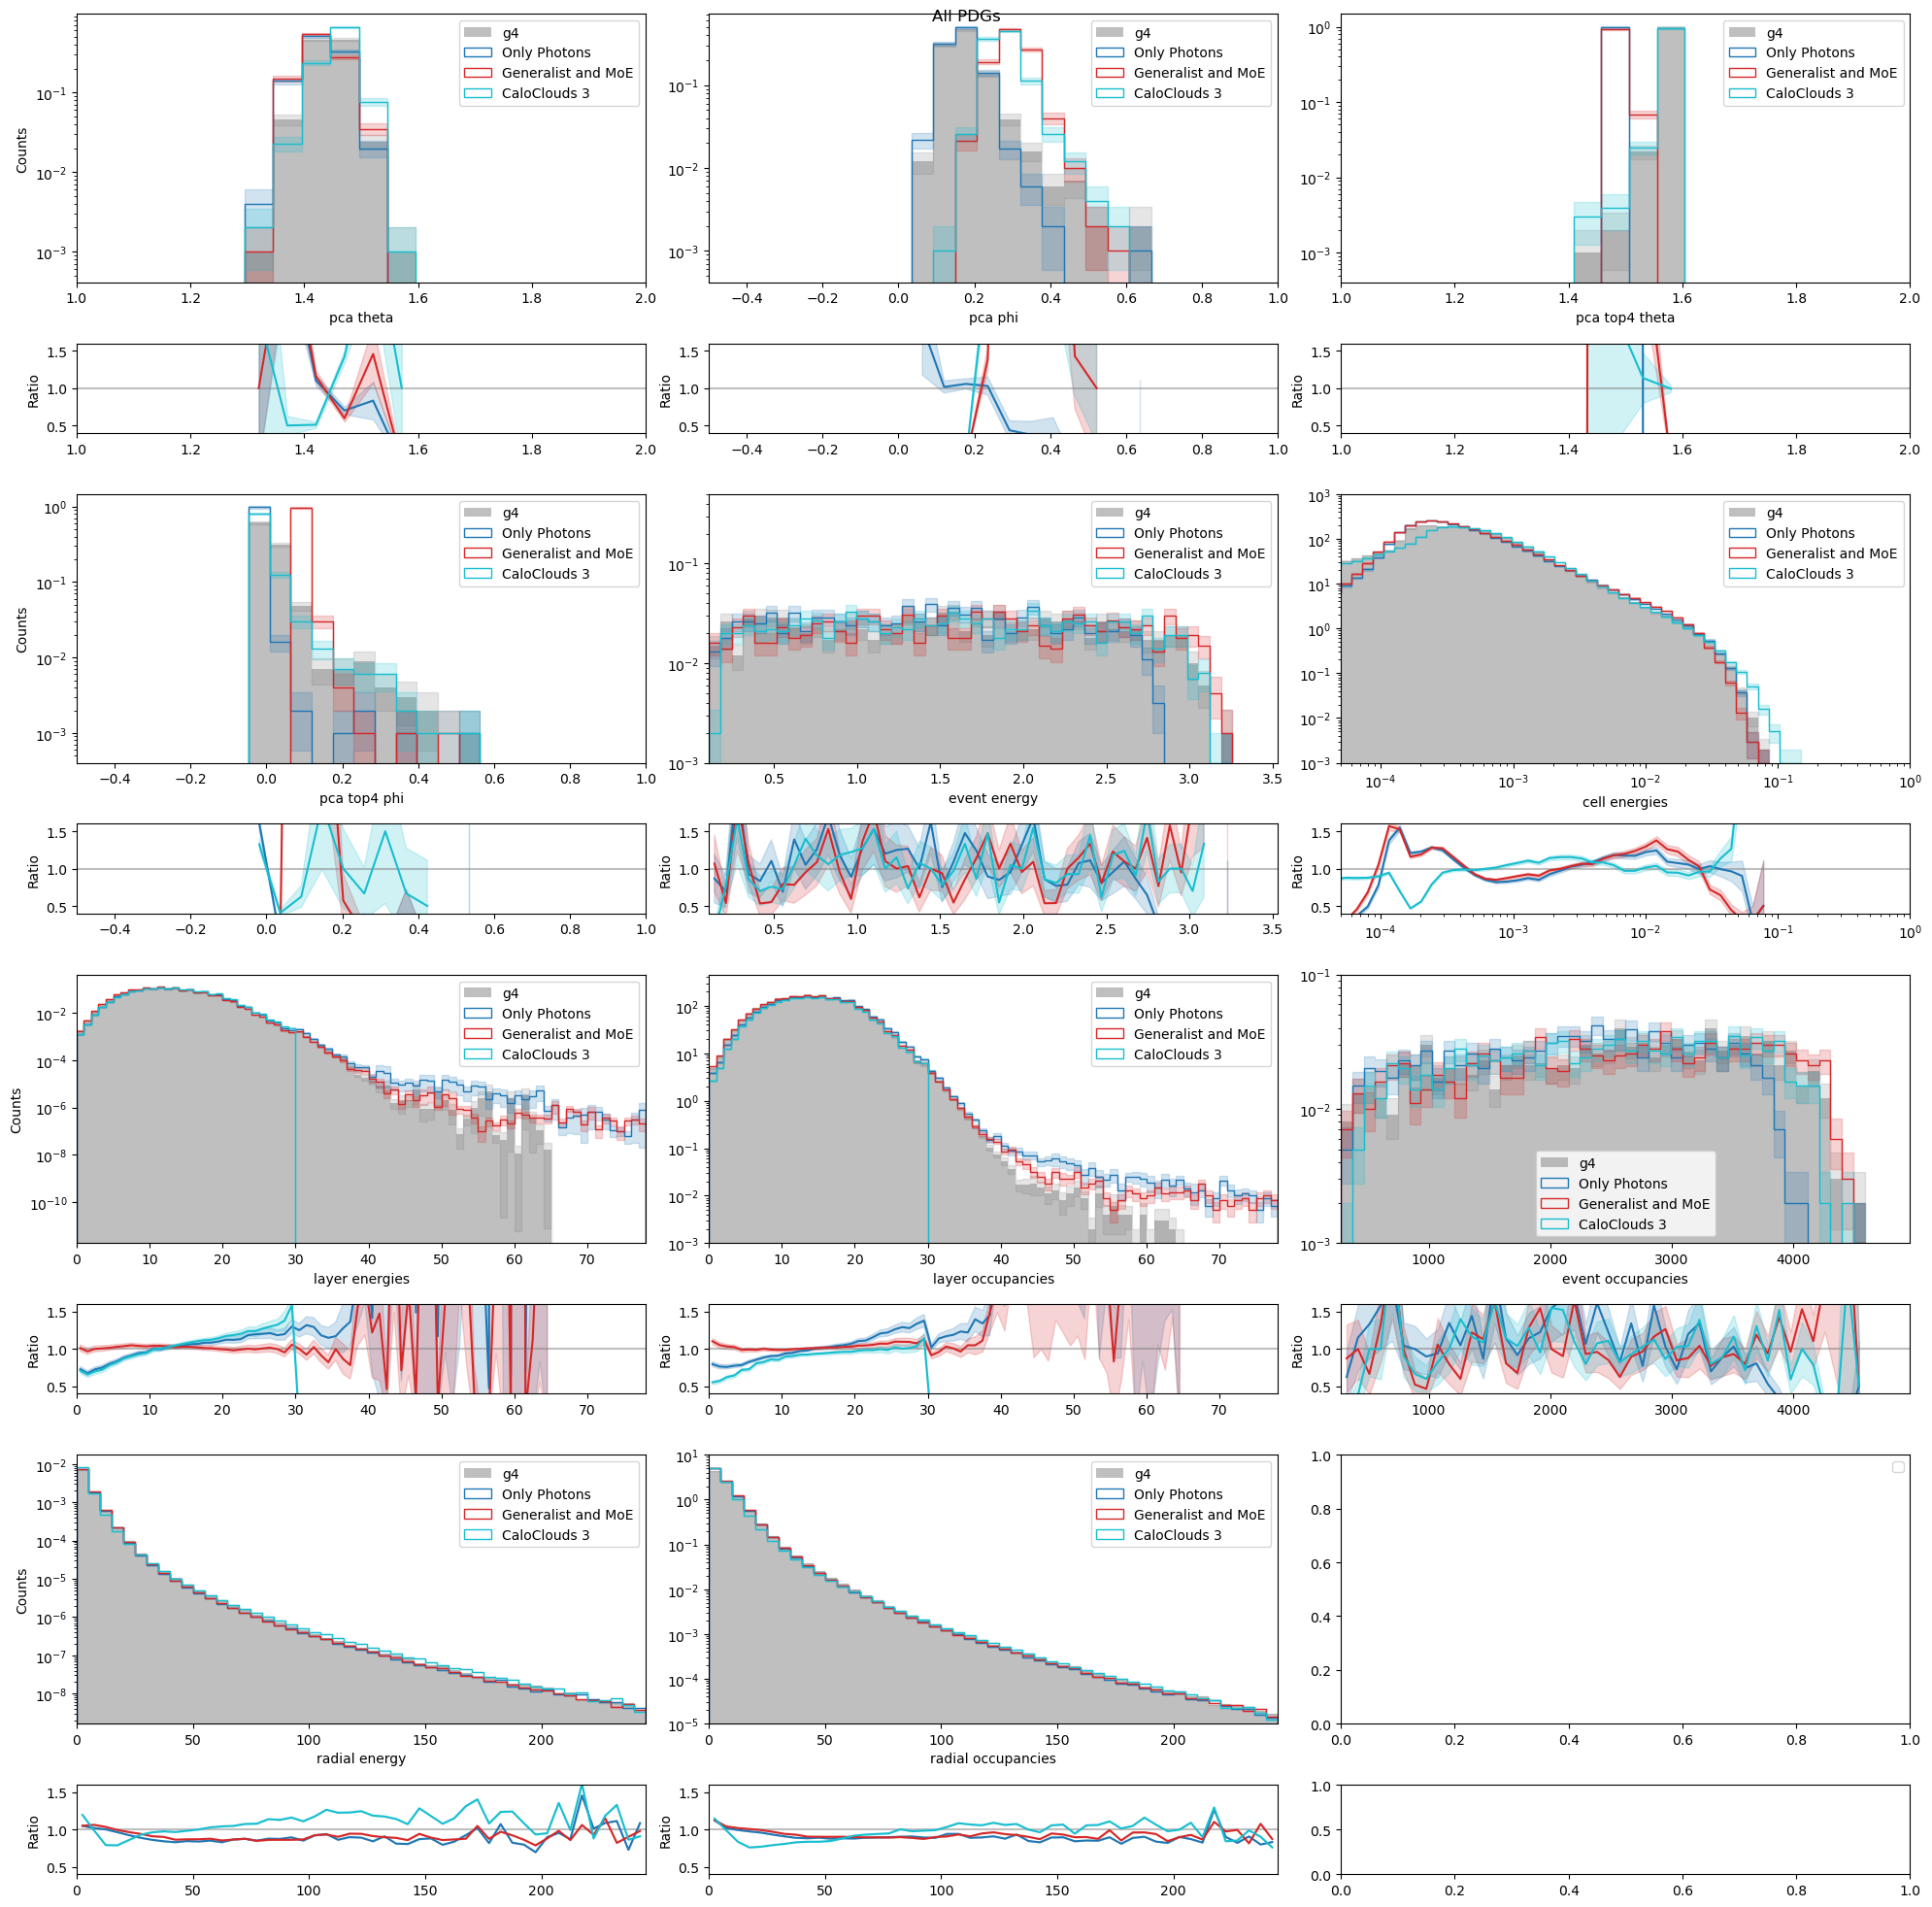

In [13]:

rescales = {0: (1, 2, None, None),
            1: (-0.5, 1, None, None),
            2: (1, 2, None, None),
            6: (-0.5, 1, None, None),
            7: (None, None, 10**-3, 0.5),
            8: (5*10**-5, 1, 10**-3, 1000),
            12: (None, None, None, None),
            13: (None, None, 10**-3, None),
            14: (None, None, 10**-3, 0.1),
            18: (None, None, None, None),
            19: (None, None, 10**-5, 10),
           }

def plot_labels(x_labels, title):    
    ref_heights = []
    ref_errors = []
    binnings = []
    for key in plot_keys:
        heights, edges, errors = bin_heights_and_edges(a_ref, key)
        ref_heights.append(heights)
        binnings.append(edges)
        ref_errors.append(errors)
    
    logx = ["cell_energies" in x_label for x_label in x_labels]
    logy = True

    pretty_x_labels = [n.replace('_', ' ') for n in x_labels]
    ratio_plots = plotting.RatioPlots(pretty_x_labels, ref_heights, binnings, logx=logx, logy=logy, truth_bin_errors=ref_errors)
    
    
    for i, sample_path in enumerate(sample_paths):
        tag = infos[i]
        sample = np.load(sample_path)
    
        a_sample = augment_with_angles(sample)
        print(sample_path)
        print(a_sample.keys())
    
        sample_heights = []
        sample_errors = []
        binnings = []
        for key in plot_keys:
            # take the pdg off if needed
            if key not in a_sample.keys():
                if key.startswith("pdg_22_"):
                    key = key[len("pdg_22_"):]
                else:
                    continue
            heights, edges, errors = bin_heights_and_edges(a_sample, key)
            sample_heights.append(heights)
            binnings.append(edges)
            sample_errors.append(errors)
        if sample_heights:
            ratio_plots.add_comparison(sample_heights, label=pretty_names[tag], colour=colours[tag], bin_errors=sample_errors)

    
    ratio_plots.fig.suptitle(title)
    ratio_plots.finalise()
    for i, ax in enumerate(ratio_plots.axes.flatten()):
        if i in rescales:
            xmin, xmax, ymin, ymax = rescales[i]
            ax.set_xlim(xmin, xmax)
            ax.set_ylim(ymin, ymax)
            ax.legend()
        #ax.set_title(str(i))
    for i, ax in enumerate(ratio_plots.axes.flatten()[3:]):
        if i in rescales:
            xmin, xmax, ymin, ymax = rescales[i]
            ax.set_xlim(xmin, xmax)
            ax.set_ylabel("Ratio")
            

        

a_ref = augment_with_angles(ref)

# collect the keys to plot (skip cond and any *_edges keys)
plot_keys = [
    key
    for key in a_ref.keys()
    if key != "cond" and not key.endswith("_edges")
    and not key.startswith("pdg_")
]
plot_labels(plot_keys, "All PDGs")


In [14]:
a_ref.keys()

dict_keys(['cond', 'pca_theta', 'pca_phi', 'pca_top4_theta', 'pca_top4_phi', 'event_energy', 'cell_energies', 'cell_energies_edges', 'layer_energies', 'layer_occupancies', 'event_occupancies', 'radial_energy', 'radial_energy_edges', 'radial_occupancies', 'radial_occupancies_edges', 'pdg_-11_cond', 'pdg_-11_pca_theta', 'pdg_-11_pca_phi', 'pdg_-11_pca_top4_theta', 'pdg_-11_pca_top4_phi', 'pdg_-11_event_energy', 'pdg_-11_cell_energies', 'pdg_-11_cell_energies_edges', 'pdg_-11_layer_energies', 'pdg_-11_layer_occupancies', 'pdg_-11_event_occupancies', 'pdg_-11_radial_energy', 'pdg_-11_radial_energy_edges', 'pdg_-11_radial_occupancies', 'pdg_-11_radial_occupancies_edges', 'pdg_11_cond', 'pdg_11_pca_theta', 'pdg_11_pca_phi', 'pdg_11_pca_top4_theta', 'pdg_11_pca_top4_phi', 'pdg_11_event_energy', 'pdg_11_cell_energies', 'pdg_11_cell_energies_edges', 'pdg_11_layer_energies', 'pdg_11_layer_occupancies', 'pdg_11_event_occupancies', 'pdg_11_radial_energy', 'pdg_11_radial_energy_edges', 'pdg_11_radi

['pdg_-11_pca_theta', 'pdg_-11_pca_phi', 'pdg_-11_pca_top4_theta', 'pdg_-11_pca_top4_phi', 'pdg_-11_event_energy', 'pdg_-11_cell_energies', 'pdg_-11_layer_energies', 'pdg_-11_layer_occupancies', 'pdg_-11_event_occupancies', 'pdg_-11_radial_energy', 'pdg_-11_radial_occupancies']
/data/dust/user/dayhallh/data/CaloClouds_diffusion/logs/2026_08_23__17_38_36/checkpoints/2026-08-24_19-58-02_ema_model_external_cond_rescaled_energy_summary.npz
dict_keys(['cond', 'pca_theta', 'pca_phi', 'pca_top4_theta', 'pca_top4_phi', 'event_energy', 'cell_energies', 'cell_energies_edges', 'layer_energies', 'layer_occupancies', 'event_occupancies', 'radial_energy', 'radial_energy_edges', 'radial_occupancies', 'radial_occupancies_edges'])
/data/dust/user/dayhallh/data/CaloClouds_diffusion/logs/2026_08_19__22_43_47/checkpoints/2026-08-21_18-01-27_ema_model_external_cond_rescaled_energy_summary.npz
dict_keys(['cond', 'pca_theta', 'pca_phi', 'pca_top4_theta', 'pca_top4_phi', 'event_energy', 'cell_energies', 'cell

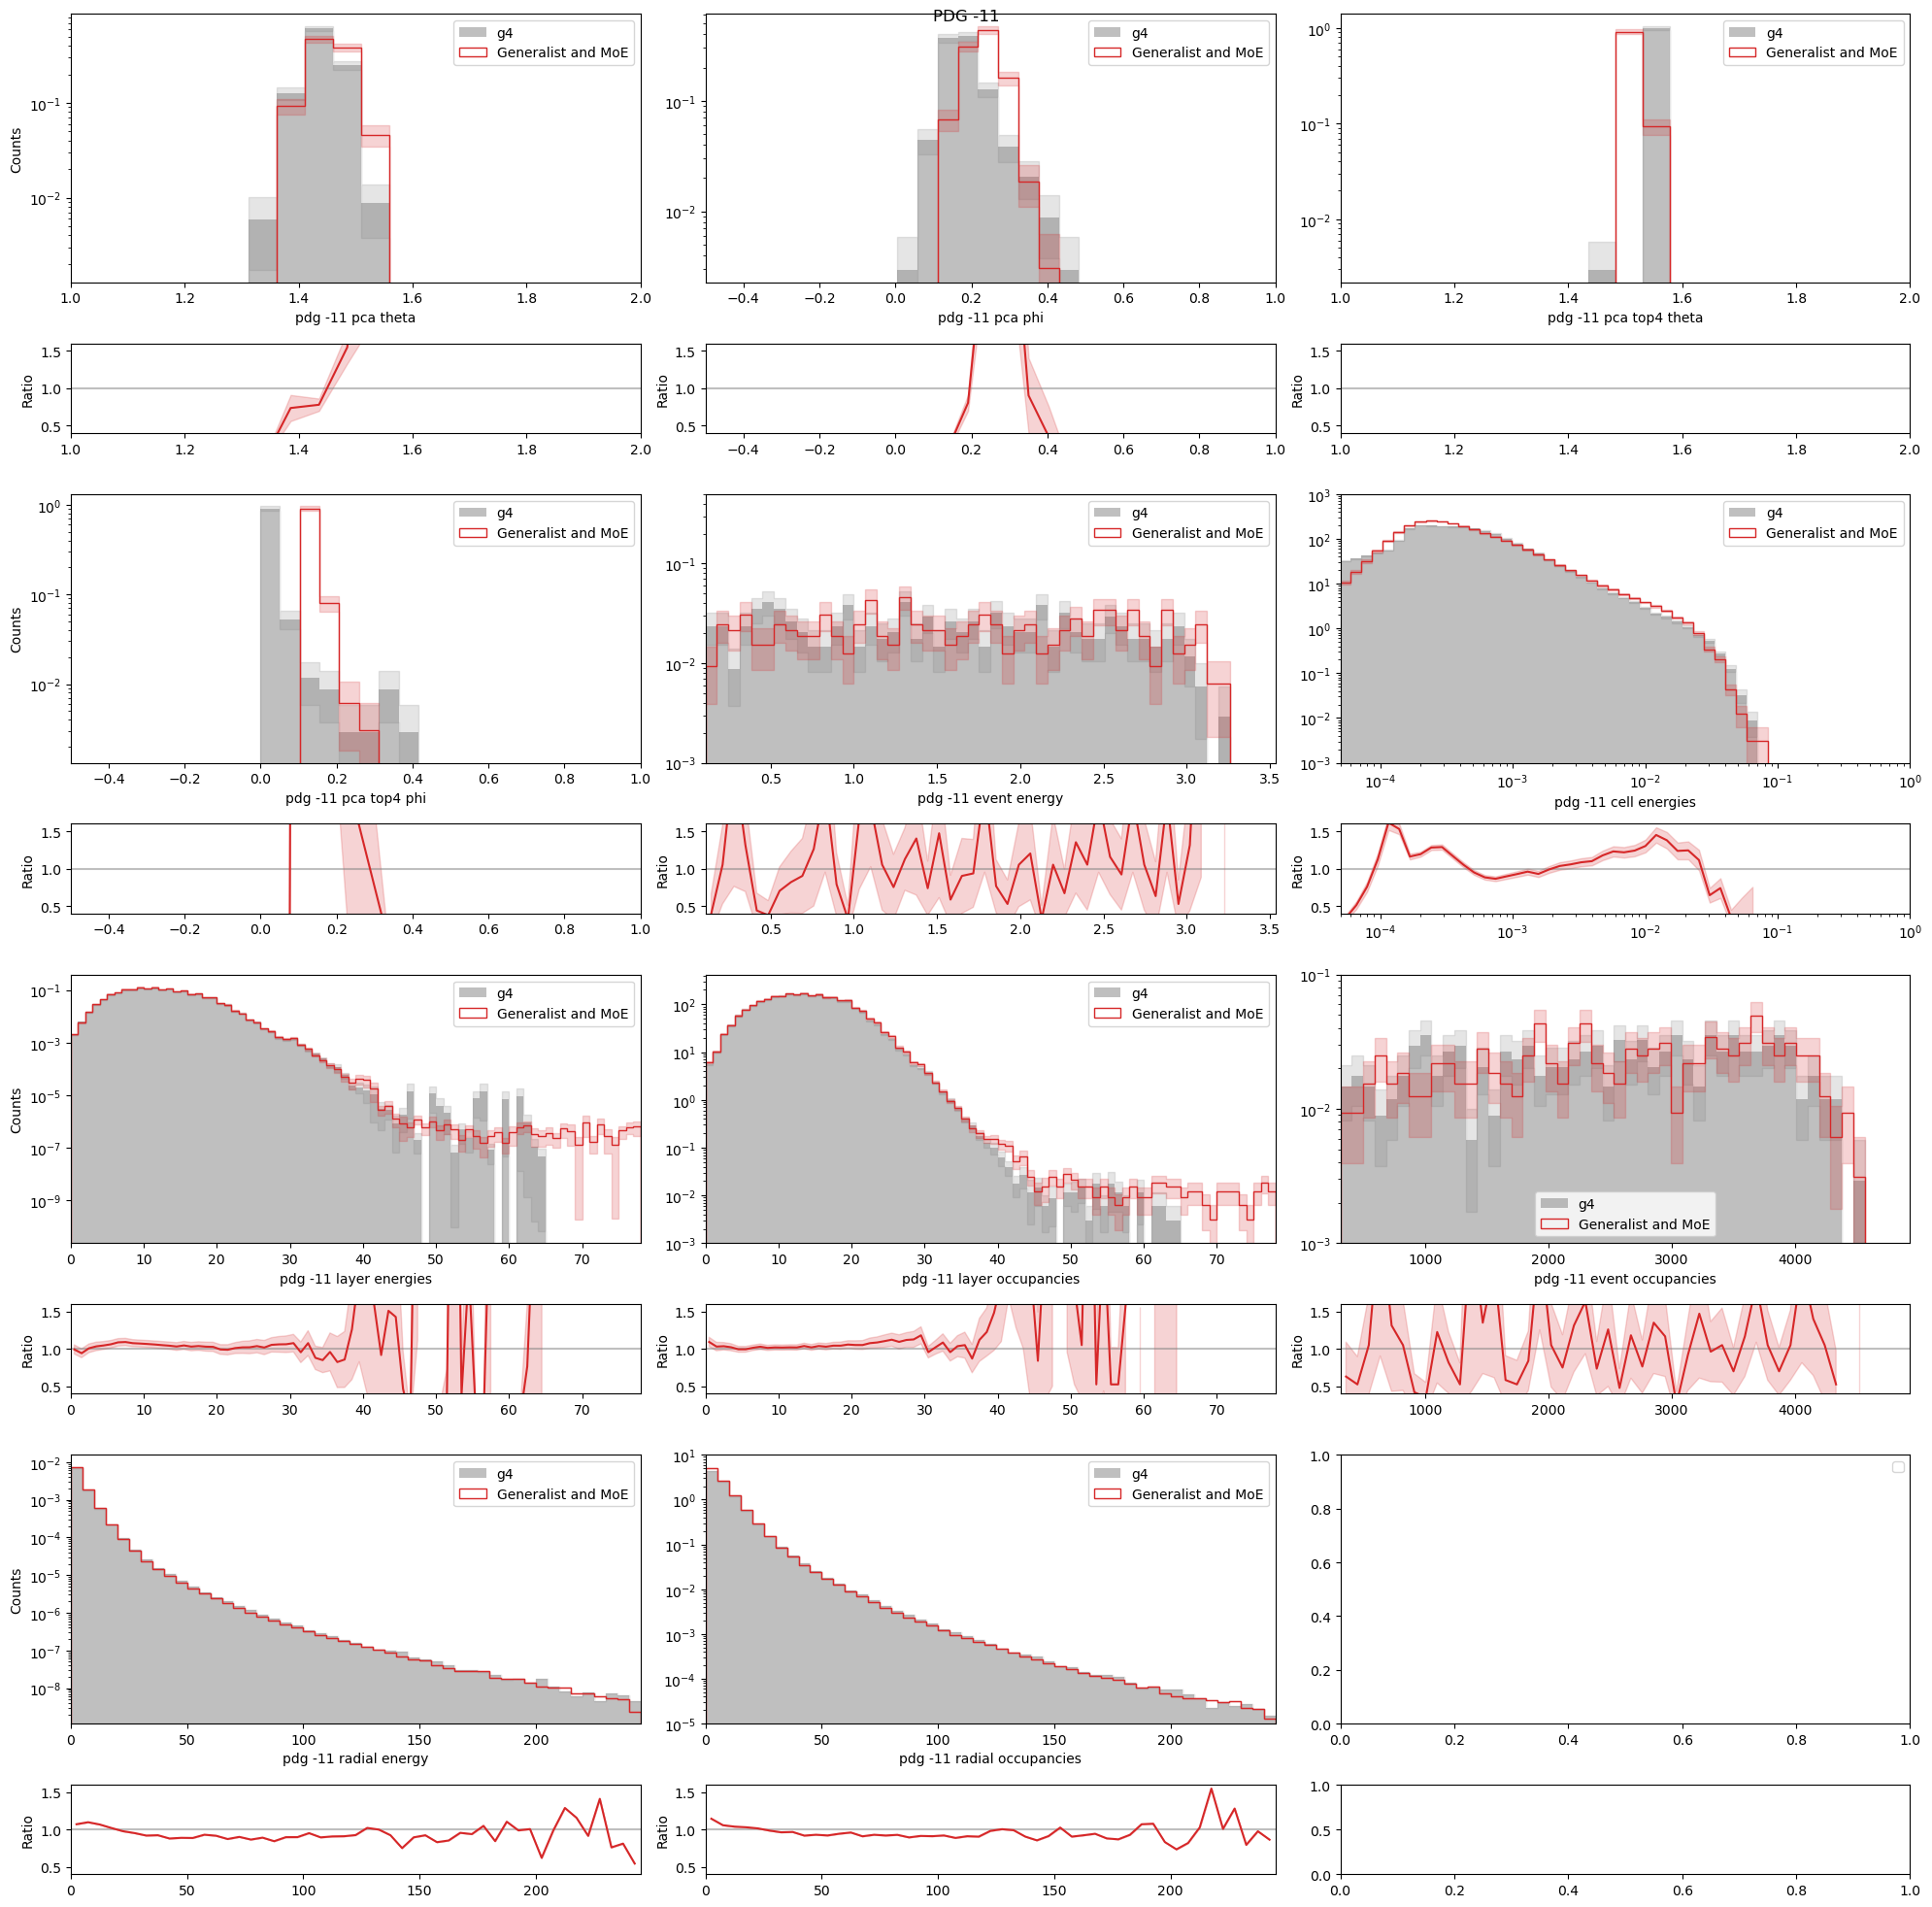

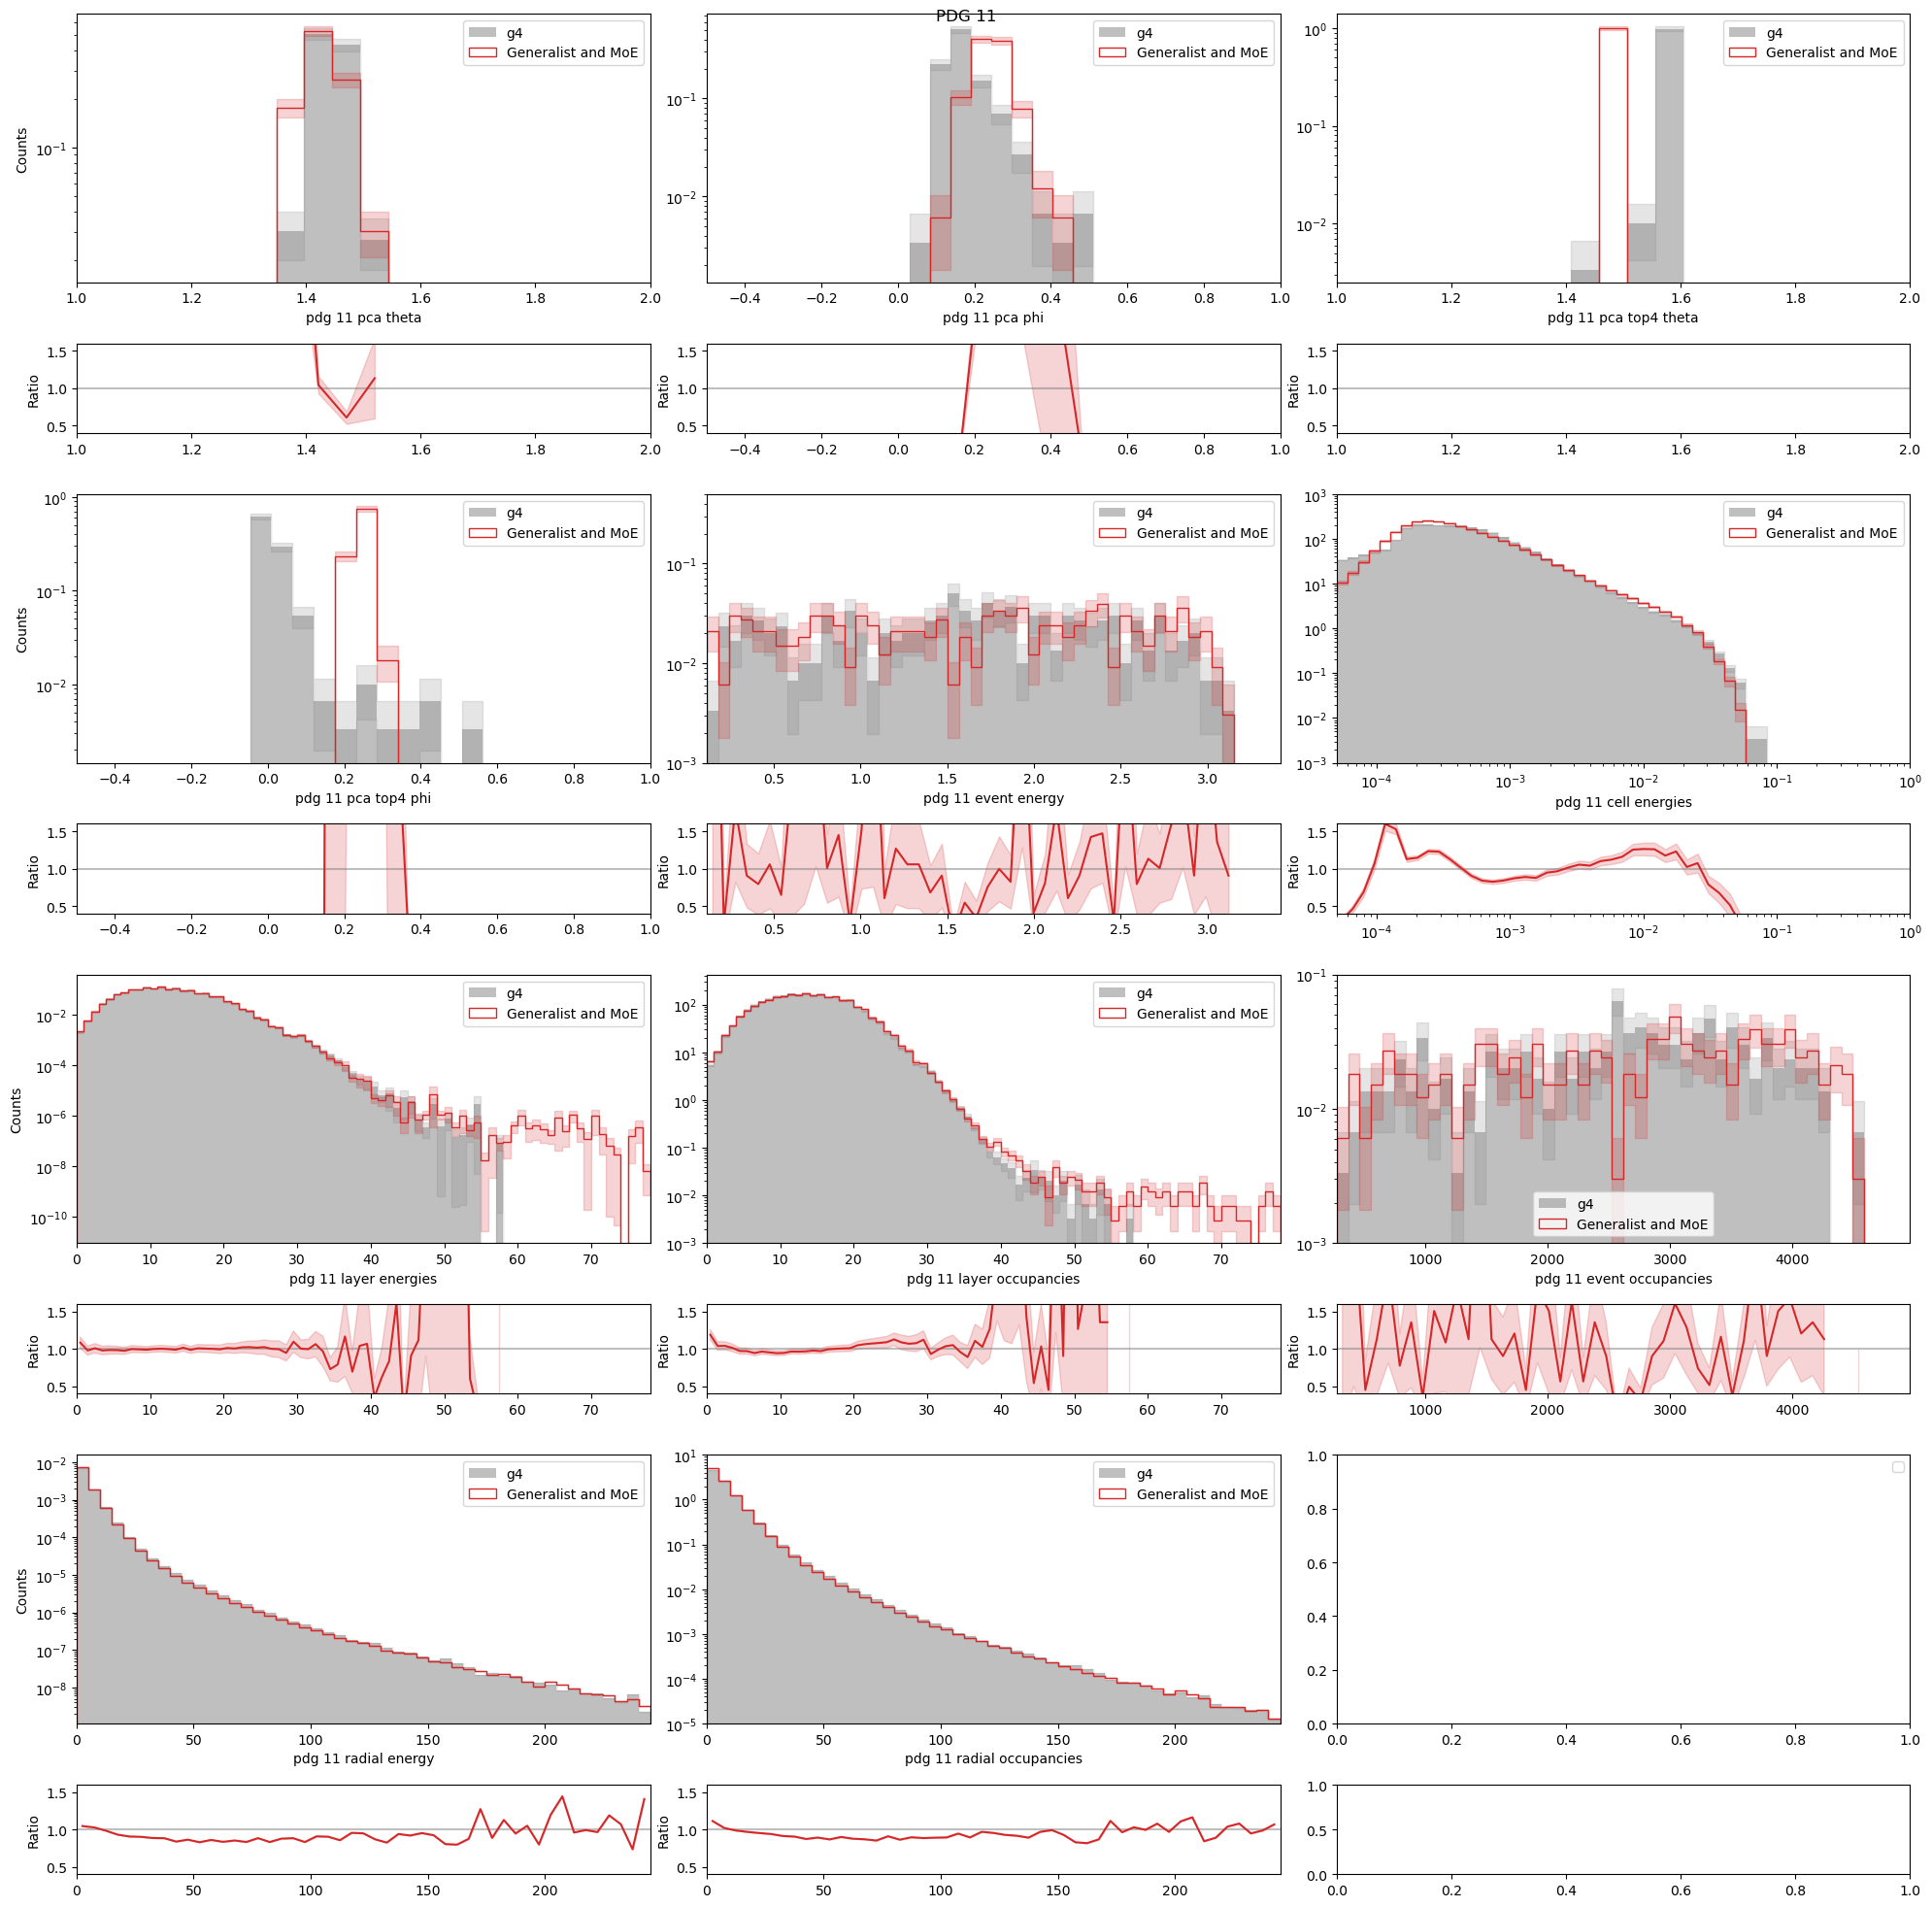

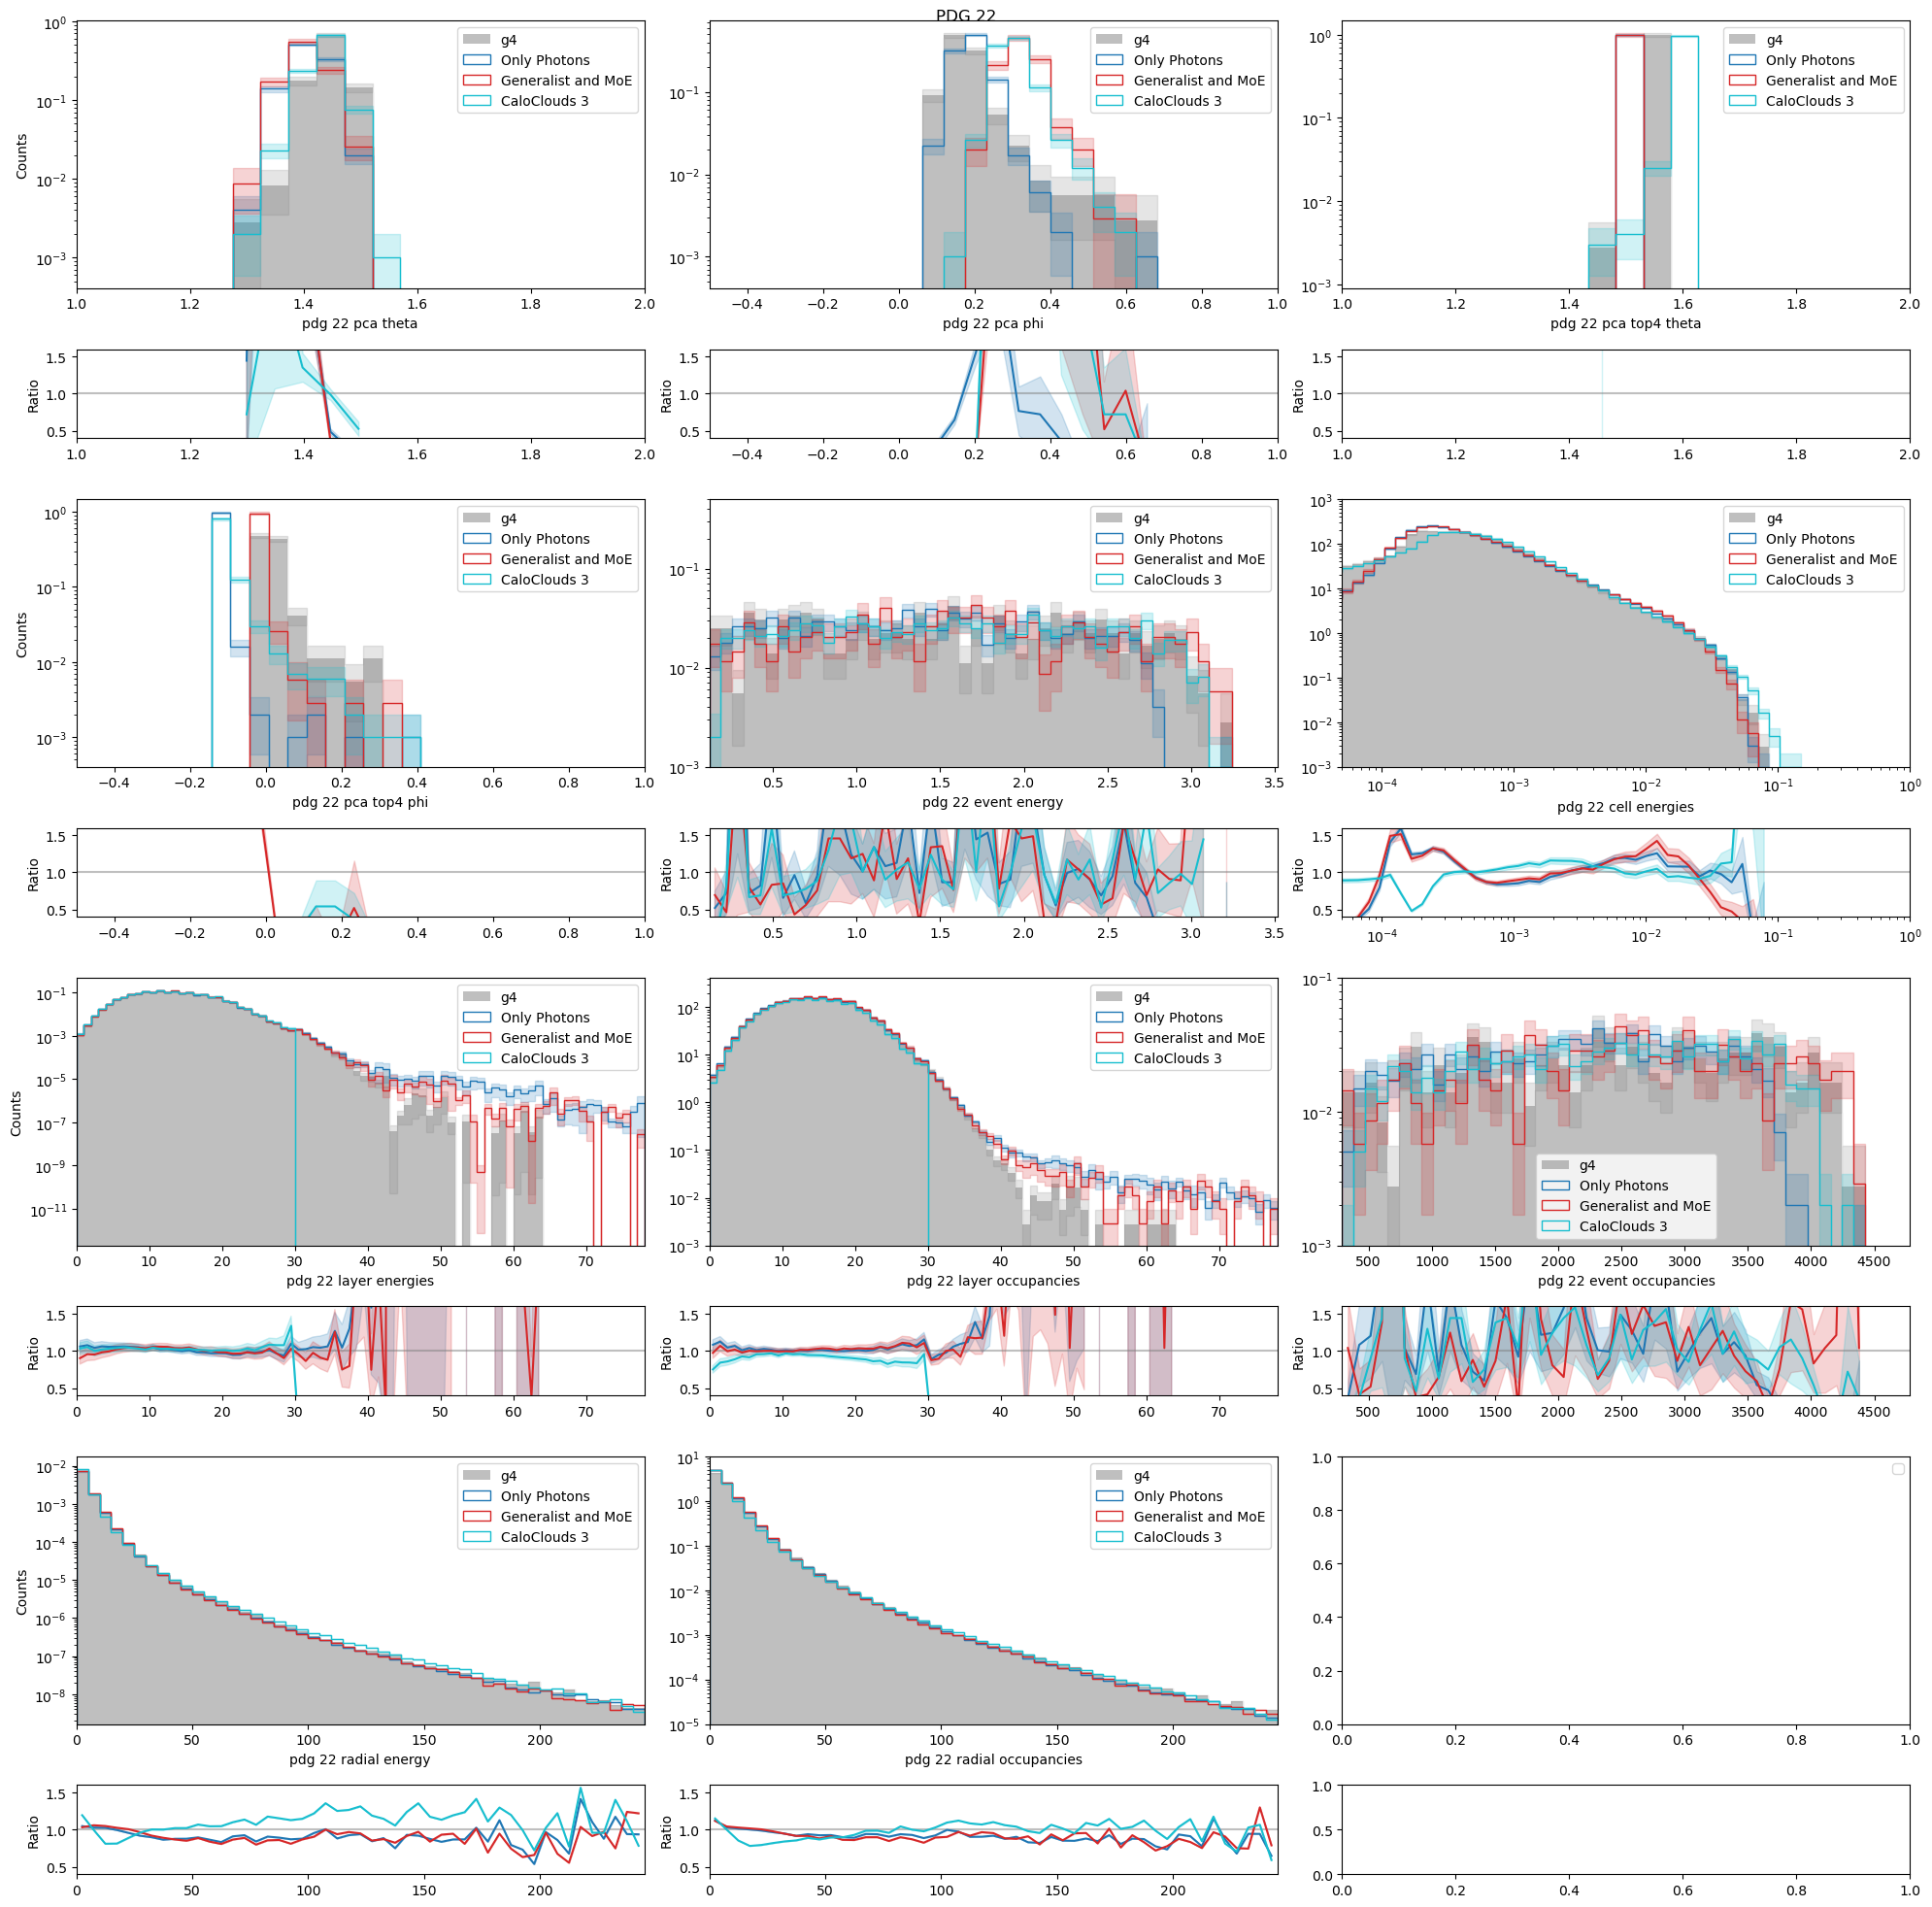

In [18]:

config = Sampler.get_config_from_model_path(best_records[-1])

pdg_list = config["simulate_pdgs"]
if len(pdg_list)>1:
    for pdg in pdg_list:
        plot_keys = [
            key
            for key in a_ref.keys()
            if ("cond" not in key) and not key.endswith("_edges")
            and key.startswith(f"pdg_{pdg}")
        ]
        print(plot_keys)
        try:
            plot_labels(plot_keys, f"PDG {pdg}")
        except Exception as e:
            print(e)
        plt.savefig(f"{save_base}_pdg{pdg}.pdf")


In [16]:
def rebin(heights, edges_old, edges_new):
    centers_old = 0.5*(edges_old[1:] + edges_old[:-1])
    heights_new = np.histogram(centers_old, bins=edges_new, weights=heights)[0]
    return heights_new


if len(pdg_list)>1:
    
    plot_keys = [
        key
        for key in a_ref.keys()
        if ("cond" not in key) and not key.endswith("_edges")
        and not key.startswith("pdg_")
    ]
    ref_heights = []
    ref_errors = []
    binnings = []
    all_edges = {}
    for key in plot_keys:
        heights, edges, errors = bin_heights_and_edges(a_ref, key)
        ref_errors.append(errors)
        all_edges[key] = edges
        ref_heights.append(heights)
        binnings.append(edges)
    
    logx = [x_label == "cell_energies" for x_label in plot_keys]
    logy = True
    pretty_x_labels = [n.replace('_', ' ') for n in plot_keys]

    ratio_plots = plotting.RatioPlots(pretty_x_labels, ref_heights, binnings, truth_label="average", logx=logx, logy=logy, truth_bin_errors=ref_errors, ratio_clip_min=0.6, ratio_clip_max=1.4)
    
    
    for i, pdg in enumerate(pdg_list):
        pdg_plot_keys = [
            key
            for key in a_ref.keys()
            if ("cond" not in key) and not key.endswith("_edges")
            and key.startswith(f"pdg_{pdg}")
        ]
        pdg_heights = []
        pdg_errors = []
        for key in pdg_plot_keys:
            my_heights, my_edges, my_errors = bin_heights_and_edges(a_ref, key)
            old_key = '_'.join(key.split('_')[2:])
            heights = rebin(my_heights, my_edges, all_edges[old_key])
            pdg_heights.append(heights)
            pdg_errors.append(my_errors)
    
        ratio_plots.add_comparison(pdg_heights, label=f"PDG {pdg}", colour=plotting.nice_hex[0][i], bin_errors=pdg_errors)
        
    ratio_plots.axes[0,0].legend()
    ratio_plots.fig.suptitle("PDG comparison")
    ratio_plots.finalise()
    for i, ax in enumerate(ratio_plots.axes.flatten()):
        if i in rescales:
            xmin, xmax, ymin, ymax = rescales[i]
            ax.set_xlim(xmin, xmax)
            ax.set_ylim(ymin, ymax)
            ax.legend()
    for i, ax in enumerate(ratio_plots.axes.flatten()[3:]):
        if i in rescales:
            xmin, xmax, ymin, ymax = rescales[i]
            ax.set_xlim(xmin, xmax)
    plt.savefig(os.path.join(img_dir, "ComparisonOfPDGs.pdf"))

In [9]:
save_

NameError: name 'save_' is not defined